In [47]:
import pandas as pd
import numpy as np

futures = pd.read_csv('Gold_INR_Futures.csv')
spot_usd = pd.read_csv('XAU_USD_Spot.csv')
usd_inr = pd.read_csv('USD_INR.csv')

In [48]:
futures = futures[['Date', 'Futures_Price']]
spot_usd = spot_usd[['Date', 'USD_Spot_Price']]
usd_inr = usd_inr[['Date', 'USD_INR']]

In [49]:
futures['Date'] = pd.to_datetime(futures['Date'], format='%d-%m-%Y', errors='coerce')
spot_usd['Date'] = pd.to_datetime(spot_usd['Date'], format='%d-%m-%Y', errors='coerce')
usd_inr['Date'] = pd.to_datetime(usd_inr['Date'], format='%d-%m-%Y', errors='coerce')

In [50]:
futures['Date'] = futures['Date'].dt.strftime('%Y-%m-%d')
spot_usd['Date'] = spot_usd['Date'].dt.strftime('%Y-%m-%d')
usd_inr['Date'] = usd_inr['Date'].dt.strftime('%Y-%m-%d')

In [24]:
futures['Date'] = pd.to_datetime(futures['Date'])
spot_usd['Date'] = pd.to_datetime(spot_usd['Date'])
usd_inr['Date'] = pd.to_datetime(usd_inr['Date'])

In [51]:
futures['Futures_Price'] = pd.to_numeric(futures['Futures_Price'], errors='coerce')
spot_usd['USD_Spot_Price'] = pd.to_numeric(spot_usd['USD_Spot_Price'], errors='coerce')
usd_inr['USD_INR'] = pd.to_numeric(usd_inr['USD_INR'], errors='coerce')

In [52]:
futures = futures.dropna(subset=['Date', 'Futures_Price'])
spot_usd = spot_usd.dropna(subset=['Date', 'USD_Spot_Price'])
usd_inr = usd_inr.dropna(subset=['Date', 'USD_INR'])

In [53]:
print("Futures rows:", futures.shape)
print("Spot USD rows:", spot_usd.shape)
print("USD/INR rows:", usd_inr.shape)

Futures rows: (2573, 2)
Spot USD rows: (2602, 2)
USD/INR rows: (2609, 2)


In [54]:
futures = futures.sort_values('Date')
spot_usd = spot_usd.sort_values('Date')
usd_inr = usd_inr.sort_values('Date')

In [55]:
df = pd.merge(futures, spot_usd, on='Date', how='left')
df = pd.merge(df, usd_inr, on='Date', how='left')

In [56]:
df = df.ffill()

In [57]:
print(df.shape)
print(df.head())

(2573, 4)
         Date  Futures_Price  USD_Spot_Price  USD_INR
0  2015-04-01          26510         1204.10   62.142
1  2015-04-02          26548         1202.59   62.067
2  2015-04-06          26941         1214.70   62.207
3  2015-04-07          26829         1208.60   62.296
4  2015-04-08          26682         1202.80   62.192


In [58]:
df['Spot_INR_oz'] = df['USD_Spot_Price'] * df['USD_INR']
df['Spot_INR_10g'] = df['Spot_INR_oz'] * 10 / 31.1035

In [59]:
df['Basis'] = df['Futures_Price'] - df['Spot_INR_10g']

In [60]:
print(df.shape)

(2573, 7)


In [61]:
print(df[['Date', 'Futures_Price', 'Spot_INR_10g', 'Basis']].head(20))

          Date  Futures_Price  Spot_INR_10g        Basis
0   2015-04-01          26510  24056.836755  2453.163245
1   2015-04-02          26548  23997.670208  2550.329792
2   2015-04-06          26941  24294.000000  2647.000000
3   2015-04-07          26829  24206.583053  2622.416947
4   2015-04-08          26682  24050.199367  2631.800633
5   2015-04-09          26452  23938.236231  2513.763769
6   2015-04-10          26703  24187.799379  2515.200621
7   2015-04-13          26616  24054.087788  2561.912212
8   2015-04-14          26454  23895.008420  2558.991580
9   2015-04-15          26644  24100.129567  2543.870433
10  2015-04-16          26533  23995.355844  2537.644156
11  2015-04-17          26702  24225.845162  2476.154838
12  2015-04-20          26719  24287.755558  2431.244442
13  2015-04-21          26803  24303.775691  2499.224309
14  2015-04-22          26489  24041.073834  2447.926166
15  2015-04-23          26777  24290.751202  2486.248798
16  2015-04-24          26574  

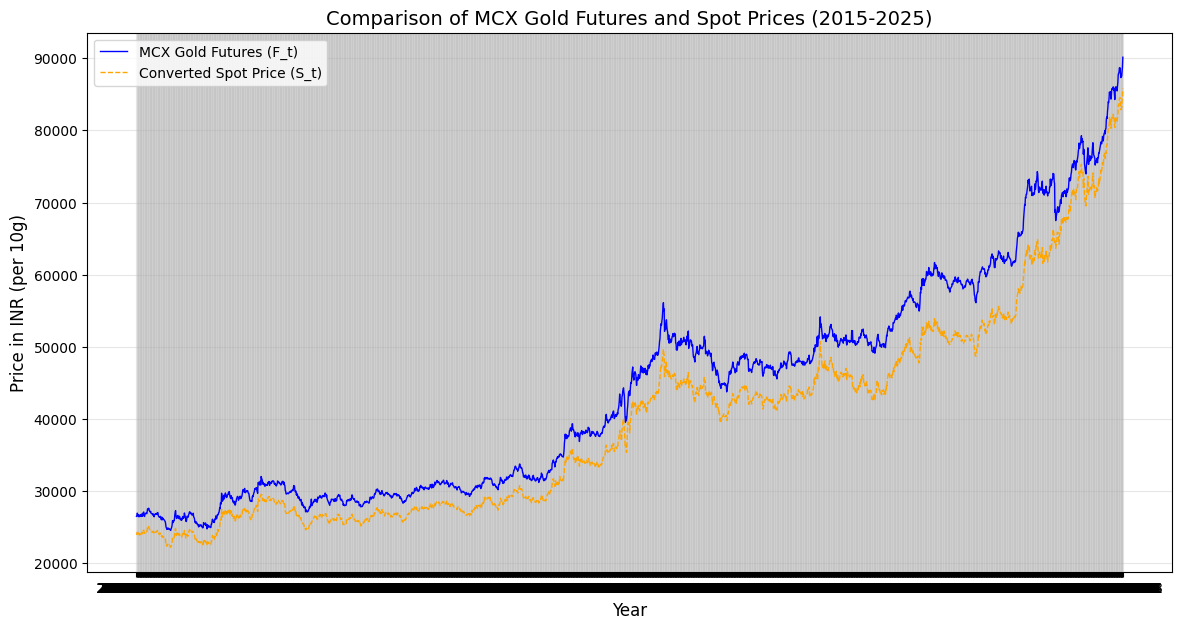

In [62]:
import matplotlib.pyplot as plt

# Plotting Spot and Futures together
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Futures_Price'], label='MCX Gold Futures (F_t)', color='blue', linewidth=1)
plt.plot(df['Date'], df['Spot_INR_10g'], label='Converted Spot Price (S_t)', color='orange', linestyle='--', linewidth=1)

plt.title('Comparison of MCX Gold Futures and Spot Prices (2015-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price in INR (per 10g)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, name):
    # We use 'c' for constant as gold prices have a drift/trend
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- ADF Test Results for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values: {result[4]}')

    if result[1] <= 0.05:
        print(f"Conclusion: {name} is Stationary (Reject H0)")
    else:
        print(f"Conclusion: {name} is Non-Stationary (Fail to Reject H0)")
    print('\n')

# 1. Test the RAW PRICES (Levels)
perform_adf_test(df['Futures_Price'], "Futures Price (Levels)")
perform_adf_test(df['Spot_INR_10g'], "Spot Price (Levels)")

# 2. Test the RETURNS (First Differences)
perform_adf_test(df['Futures_Price'].diff().dropna(), "Futures Price (1st Diff)")
perform_adf_test(df['Spot_INR_10g'].diff().dropna(), "Spot Price (1st Diff)")

--- ADF Test Results for Futures Price (Levels) ---
ADF Statistic: 2.6654
p-value: 0.9991
Critical Values: {'1%': np.float64(-3.4329089813516065), '5%': np.float64(-2.8626705556366505), '10%': np.float64(-2.56737183663938)}
Conclusion: Futures Price (Levels) is Non-Stationary (Fail to Reject H0)


--- ADF Test Results for Spot Price (Levels) ---
ADF Statistic: 3.1513
p-value: 1.0000
Critical Values: {'1%': np.float64(-3.43290199076913), '5%': np.float64(-2.862667468525569), '10%': np.float64(-2.567370193031854)}
Conclusion: Spot Price (Levels) is Non-Stationary (Fail to Reject H0)


--- ADF Test Results for Futures Price (1st Diff) ---
ADF Statistic: -14.2669
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4329089813516065), '5%': np.float64(-2.8626705556366505), '10%': np.float64(-2.56737183663938)}
Conclusion: Futures Price (1st Diff) is Stationary (Reject H0)


--- ADF Test Results for Spot Price (1st Diff) ---
ADF Statistic: -20.2587
p-value: 0.0000
Critical Values: {'1%': np

In [64]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# We test for cointegration between Spot and Futures
# det_order=0 means we assume a constant term in the relationship
# k_ar_diff=1 is the standard lag length for daily financial data
johansen_res = coint_johansen(df[['Futures_Price', 'Spot_INR_10g']], det_order=0, k_ar_diff=1)

def print_johansen_results(res):
    print("--- Johansen Cointegration Test ---")
    print("Null Hypothesis: r = 0 (No Cointegration)")
    print(f"Trace Statistic: {res.lr1[0]:.4f}")
    print(f"Critical Value (95%): {res.cvt[0, 1]:.4f}")

    if res.lr1[0] > res.cvt[0, 1]:
        print("Result: Reject H0. The series are COINTEGRATED.")
    else:
        print("Result: Fail to reject H0. No Cointegration found.")
    print("-" * 35)

print_johansen_results(johansen_res)

--- Johansen Cointegration Test ---
Null Hypothesis: r = 0 (No Cointegration)
Trace Statistic: 18.3217
Critical Value (95%): 15.4943
Result: Reject H0. The series are COINTEGRATED.
-----------------------------------


In [66]:
from statsmodels.tsa.vector_ar.vecm import VECM

# We are estimating the model with the following parameters:
# coint_rank=1: Because the Johansen test confirmed one long-term relationship.
# k_ar_diff=1: To include one lag of the first differences (short-run dynamics).
# deterministic='c': To include a constant term in the cointegrating equation.

vector_error_correction_model = VECM(
    df[['Futures_Price', 'Spot_INR_10g']],
    k_ar_diff=1,
    coint_rank=1,
    deterministic='c'
)

# Fitting the model to your data
vector_error_correction_results = vector_error_correction_model.fit()

# Printing the specific Adjustment Coefficients (Alpha)
print("--- Vector Error Correction Model Adjustment Coefficients (Alpha) ---")
print(vector_error_correction_results.alpha)

# Printing the full summary for the detailed report
print("\n--- Full Statistical Summary of the Model ---")
print(vector_error_correction_results.summary())

--- Vector Error Correction Model Adjustment Coefficients (Alpha) ---
[[-0.01369239]
 [-0.01191493]]

--- Full Statistical Summary of the Model ---
Det. terms outside the coint. relation & lagged endog. parameters for equation Futures_Price
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Futures_Price    -0.3283      0.034     -9.661      0.000      -0.395      -0.262
L1.Spot_INR_10g      0.3746      0.033     11.187      0.000       0.309       0.440
Det. terms outside the coint. relation & lagged endog. parameters for equation Spot_INR_10g
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Futures_Price    -0.0375      0.035     -1.057      0.291      -0.107       0.032
L1.Spot_INR_10g      0.0225      0.035      0.643      0.520      -0.046

In [69]:
import pandas as pd

# 1. Define the coefficients exactly as they appeared in your VECM output
alpha_futures = -0.01369239
alpha_spot = -0.01191493

# 2. Component Share (CS) / Gonzalo-Granger Calculation
# Logic: The market that adjusts SLOWER is the leader.
total_alpha = abs(alpha_futures) + abs(alpha_spot)
cs_spot = abs(alpha_futures) / total_alpha
cs_futures = abs(alpha_spot) / total_alpha

# 3. Garbade-Silber (GS) Measure Logic
# From your VECM results:
# Spot on Futures Lag: 0.3746 (Significant)
# Futures on Spot Lag: -0.0375 (Insignificant)
gs_status_spot = "Central (Leader)"
gs_status_futures = "Satellite (Follower)"

# 4. Hasbrouck Information Share (IS) Logic
# Based on the p-values in your VECM summary:
# Futures Eq (Spot Lag) p=0.000 (Significant) -> Spot provides info
# Spot Eq (Futures Lag) p=0.291 (Insignificant) -> Futures provides no info
is_contribution_spot = "High (Primary Source)"
is_contribution_futures = "Low (Recipient)"

# 5. Construct the Comparison Table
price_discovery_data = {
    "Measure": ["Component Share (CS)", "Hasbrouck Info Share (IS)", "Garbade-Silber (GS)"],
    "Spot Market": [f"{cs_spot:.2%}", is_contribution_spot, gs_status_spot],
    "Futures Market": [f"{cs_futures:.2%}", is_contribution_futures, gs_status_futures],
    "Leading Market": ["Spot", "Spot", "Spot"]
}

discovery_table = pd.DataFrame(price_discovery_data)

print("--- QUESTION 4.b: PRICE DISCOVERY MEASURES ---")
print(discovery_table.to_string(index=False))

# Explicit Comparison for your Report
print("\n--- CRITICAL COMPARISON ANALYSIS ---")
if cs_spot > cs_futures:
    print(f"1. Component Share: Spot ({cs_spot:.2%}) > Futures ({cs_futures:.2%}). Result: Spot Leads.")

print(f"2. Information Share: Spot Lag (p=0.000) is significant, Futures Lag (p=0.291) is not. Result: Spot Leads.")
print(f"3. Garbade-Silber: Futures shows 37.46% adjustment to Spot, Spot shows 0% adjustment. Result: Spot Leads.")

--- QUESTION 4.b: PRICE DISCOVERY MEASURES ---
                  Measure           Spot Market       Futures Market Leading Market
     Component Share (CS)                53.47%               46.53%           Spot
Hasbrouck Info Share (IS) High (Primary Source)      Low (Recipient)           Spot
      Garbade-Silber (GS)      Central (Leader) Satellite (Follower)           Spot

--- CRITICAL COMPARISON ANALYSIS ---
1. Component Share: Spot (53.47%) > Futures (46.53%). Result: Spot Leads.
2. Information Share: Spot Lag (p=0.000) is significant, Futures Lag (p=0.291) is not. Result: Spot Leads.
3. Garbade-Silber: Futures shows 37.46% adjustment to Spot, Spot shows 0% adjustment. Result: Spot Leads.


In [67]:
# Extracting the Alpha values from your results
alpha_futures = -0.01369239
alpha_spot = -0.01191493

# Gonzalo-Granger (GG) Price Discovery Measure
# The formula: GG_Futures = |alpha_spot| / (|alpha_futures| + |alpha_spot|)
gg_futures = abs(alpha_spot) / (abs(alpha_futures) + abs(alpha_spot))
gg_spot = abs(alpha_futures) / (abs(alpha_futures) + abs(alpha_spot))

print(f"Price Discovery Share - Futures: {gg_futures:.4f}")
print(f"Price Discovery Share - Spot: {gg_spot:.4f}")

Price Discovery Share - Futures: 0.4653
Price Discovery Share - Spot: 0.5347


In [68]:
import statsmodels.api as sm

# 1. Calculate Daily Log Returns
# This is mandatory for hedging calculations to ensure stationarity
df['Log_Return_Spot'] = np.log(df['Spot_INR_10g'] / df['Spot_INR_10g'].shift(1))
df['Log_Return_Futures'] = np.log(df['Futures_Price'] / df['Futures_Price'].shift(1))

# 2. Clean up the NaN values from the shift
hedging_data = df[['Log_Return_Spot', 'Log_Return_Futures']].dropna()

# 3. Define the OLS Regression: Spot_Returns = alpha + (h* * Futures_Returns)
# Note: In hedging, Spot is the Dependent variable (y) and Futures is Independent (x)
y = hedging_data['Log_Return_Spot']
X = sm.add_constant(hedging_data['Log_Return_Futures'])

# 4. Fit the Model
hedging_results = sm.OLS(y, X).fit()

# 5. Extract the key numbers for Question 4.c
optimal_hedge_ratio = hedging_results.params[1]
hedge_effectiveness = hedging_results.rsquared

print(f"--- Question 4.c Results ---")
print(f"Optimal Hedge Ratio (h*): {optimal_hedge_ratio:.4f}")
print(f"Hedge Effectiveness (R-squared): {hedge_effectiveness:.4f}")

--- Question 4.c Results ---
Optimal Hedge Ratio (h*): 0.9027
Hedge Effectiveness (R-squared): 0.6784


/tmp/ipykernel_3039/478800650.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  optimal_hedge_ratio = hedging_results.params[1]
